<a href="https://colab.research.google.com/github/ishikakumar227-sys/smartkart-customer-churn-intelligence/blob/main/AMAZON_AI_ML_FRAUD_DETECTION_PIPELINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Created Successfully
   transaction_amount  customer_age  account_age_days  previous_transactions  \
0          703.902135            39               614                    453   
1         4515.182146            19              1104                     10   
2         1975.118540            21               793                    457   
3         1369.413831            62              2651                    177   
4          254.437306            30                67                    398   

   failed_login_attempts  transactions_last_24h  distance_from_usual_location  \
0                      1                     11                      5.791484   
1                      1                      7                     38.019766   
2                      0                      8                      5.900337   
3                      0                     13                     41.038463   
4                      0                     12                     49.050615   

   

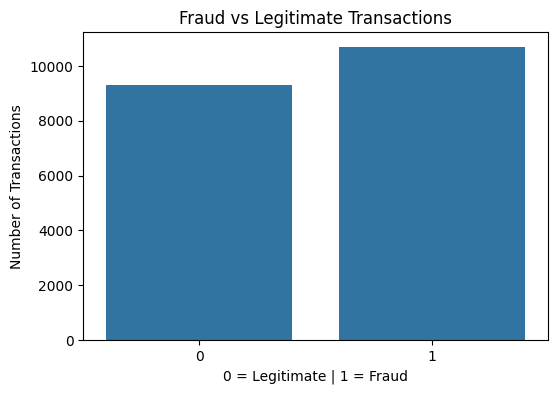


Model Training Completed!

========== MODEL PERFORMANCE ==========
Accuracy : 0.7248
Precision: 0.7547
Recall   : 0.719
F1 Score : 0.7364
ROC-AUC  : 0.796

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Legitimate       0.69      0.73      0.71      1861
       Fraud       0.75      0.72      0.74      2139

    accuracy                           0.72      4000
   macro avg       0.72      0.73      0.72      4000
weighted avg       0.73      0.72      0.73      4000



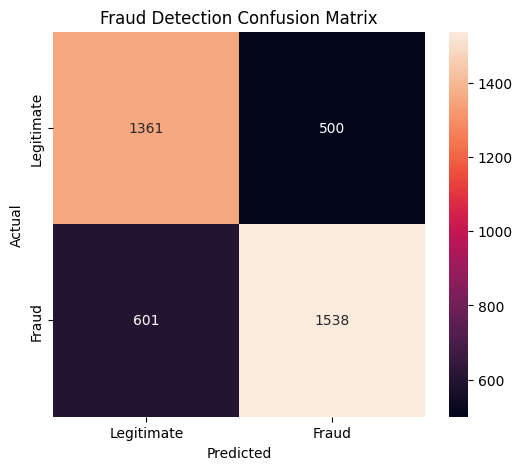


========== FEATURE IMPORTANCE ==========
                         Feature  Importance
0             transaction_amount    0.199458
7             device_changes_30d    0.174785
6   distance_from_usual_location    0.116074
5          transactions_last_24h    0.109713
2               account_age_days    0.094906
3          previous_transactions    0.091272
1                   customer_age    0.077285
8      international_transaction    0.049038
4          failed_login_attempts    0.038142
9                     new_device    0.030652
10             night_transaction    0.018676


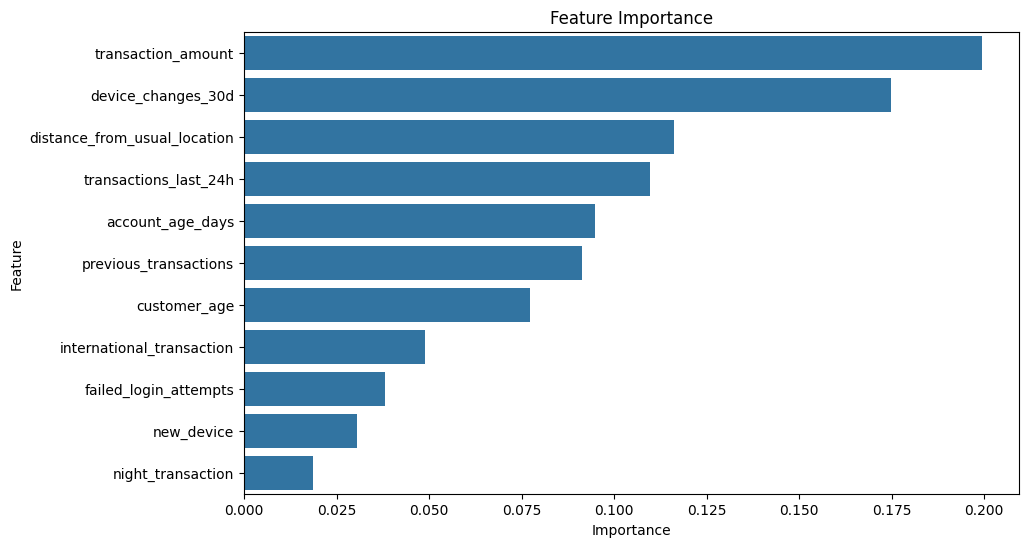


========== NEW TRANSACTION ==========
Fraud Probability: 93.54 %
Prediction: FRAUDULENT TRANSACTION
Risk Level: HIGH RISK

Results saved successfully!
File: amazon_fraud_detection_results.csv


In [1]:
# AMAZON - AI/ML FRAUD DETECTION PIPELINE
# Google Colab Ready

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)

# --------------------------------------------------
# 1. CREATE DATASET
# --------------------------------------------------

np.random.seed(42)

n = 20000

df = pd.DataFrame({
    "transaction_amount": np.random.exponential(1500, n),
    "customer_age": np.random.randint(18, 70, n),
    "account_age_days": np.random.randint(1, 3000, n),
    "previous_transactions": np.random.randint(1, 500, n),
    "failed_login_attempts": np.random.poisson(0.5, n),
    "transactions_last_24h": np.random.randint(1, 20, n),
    "distance_from_usual_location": np.random.exponential(20, n),
    "device_changes_30d": np.random.randint(0, 6, n),
    "international_transaction": np.random.randint(0, 2, n),
    "new_device": np.random.randint(0, 2, n),
    "night_transaction": np.random.randint(0, 2, n)
})

# --------------------------------------------------
# 2. GENERATE FRAUD LABEL
# --------------------------------------------------

risk = (
    0.0008 * df["transaction_amount"]
    + 0.8 * df["failed_login_attempts"]
    + 0.15 * df["transactions_last_24h"]
    + 0.025 * df["distance_from_usual_location"]
    + 0.8 * df["device_changes_30d"]
    + 1.5 * df["international_transaction"]
    + 1.2 * df["new_device"]
    + 0.7 * df["night_transaction"]
    + np.random.normal(0, 2, n)
)

probability = 1 / (1 + np.exp(-(risk - 7)))

df["fraud"] = np.random.binomial(1, probability)

print("Dataset Created Successfully")
print(df.head())

# --------------------------------------------------
# 3. DATA INFORMATION
# --------------------------------------------------

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFraud Distribution:")
print(df["fraud"].value_counts())

# --------------------------------------------------
# 4. VISUALIZATION
# --------------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x="fraud", data=df)
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("0 = Legitimate | 1 = Fraud")
plt.ylabel("Number of Transactions")
plt.show()

# --------------------------------------------------
# 5. FEATURES AND TARGET
# --------------------------------------------------

X = df.drop("fraud", axis=1)
y = df["fraud"]

# --------------------------------------------------
# 6. TRAIN TEST SPLIT
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# 7. FEATURE SCALING
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------------
# 8. TRAIN ML MODEL
# --------------------------------------------------

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed!")

# --------------------------------------------------
# 9. PREDICTIONS
# --------------------------------------------------

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# --------------------------------------------------
# 10. MODEL EVALUATION
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n========== MODEL PERFORMANCE ==========")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraud"]
))

# --------------------------------------------------
# 11. CONFUSION MATRIX
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fraud Detection Confusion Matrix")
plt.show()

# --------------------------------------------------
# 12. FEATURE IMPORTANCE
# --------------------------------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n========== FEATURE IMPORTANCE ==========")
print(importance)

plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)
plt.title("Feature Importance")
plt.show()

# --------------------------------------------------
# 13. TEST A NEW TRANSACTION
# --------------------------------------------------

new_transaction = pd.DataFrame({
    "transaction_amount": [8500],
    "customer_age": [25],
    "account_age_days": [30],
    "previous_transactions": [15],
    "failed_login_attempts": [3],
    "transactions_last_24h": [12],
    "distance_from_usual_location": [180],
    "device_changes_30d": [4],
    "international_transaction": [1],
    "new_device": [1],
    "night_transaction": [1]
})

new_scaled = scaler.transform(new_transaction)

prediction = model.predict(new_scaled)[0]
fraud_probability = model.predict_proba(new_scaled)[0][1]

print("\n========== NEW TRANSACTION ==========")
print("Fraud Probability:",
      round(fraud_probability * 100, 2), "%")

if prediction == 1:
    print("Prediction: FRAUDULENT TRANSACTION")
else:
    print("Prediction: LEGITIMATE TRANSACTION")

# --------------------------------------------------
# 14. RISK LEVEL
# --------------------------------------------------

if fraud_probability >= 0.75:
    risk_level = "HIGH RISK"
elif fraud_probability >= 0.40:
    risk_level = "MEDIUM RISK"
else:
    risk_level = "LOW RISK"

print("Risk Level:", risk_level)

# --------------------------------------------------
# 15. SAVE RESULTS
# --------------------------------------------------

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Fraud_Probability": y_prob
})

results.to_csv(
    "amazon_fraud_detection_results.csv",
    index=False
)

print("\nResults saved successfully!")
print("File: amazon_fraud_detection_results.csv")